In [2]:
import sys
sys.path.append('..')

import pandas as pd
from datasets.loader import load_files, load_npy_file, load_json_file
from evaluation.visualization import plot_histories
import matplotlib.pyplot as plt
from datasets.paths import ProjectPaths
import numpy as np
import math


In [3]:
pd.set_option("display.max_columns", None)


In [4]:
paths = ProjectPaths()


In [5]:
histories = load_files(paths.models_dir, "history.npy", load_npy_file)
print(histories.keys())


dict_keys(['bilstm_attention_cosine', 'bilstm_attention_cosine_aug', 'bilstm_mean_cosine', 'bilstm_mean_cosine_aug', 'lstm_attention_cosine', 'lstm_last_manhattan', 'lstm_mean_cosine', 'lstm_mean_manhattan', 'lstm_mean_mlp'])


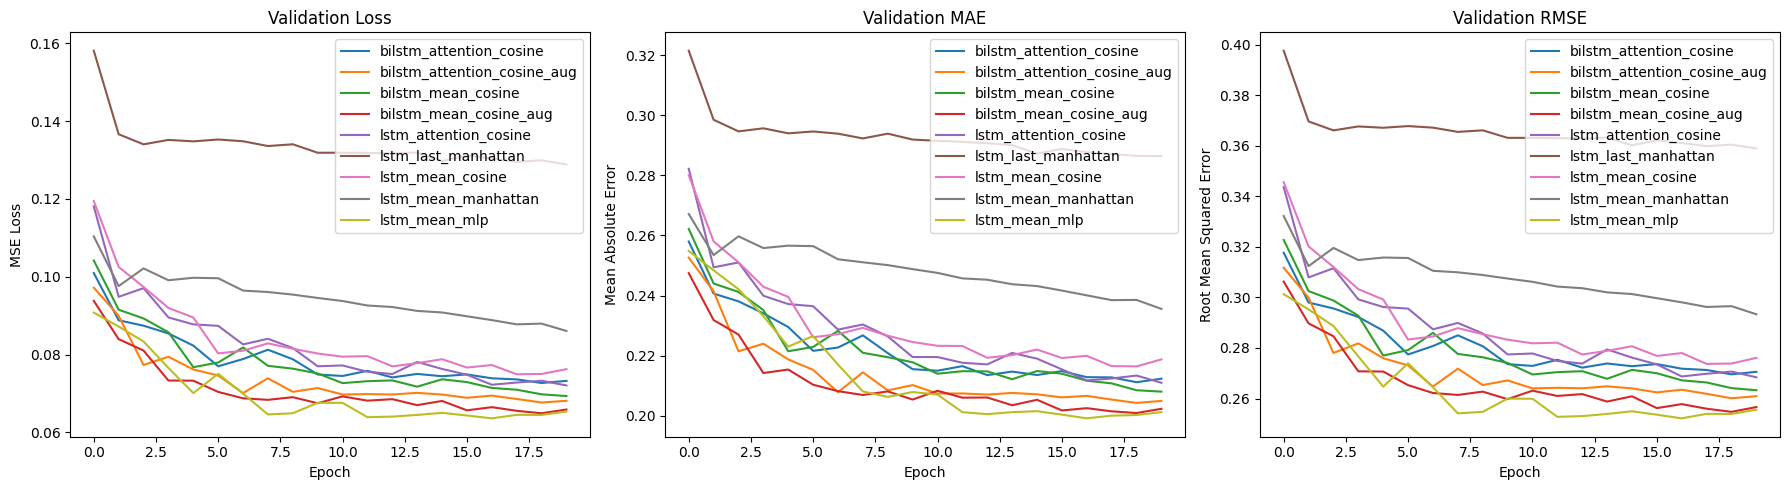

In [6]:
plot_histories(histories, paths.models_dir)


In [7]:
metrics = load_files(paths.models_dir, "metrics.json", load_json_file)
print(len(metrics))
 

9


In [8]:
df = pd.DataFrame(metrics.values())
display(df)


,name,hidden_dim,embedding_dim,embedding_trainable,pooling,similarity,bidirectional,mlp_layers,concat_features,mlp_dropout,lstm_dropout,trainable_params,sequence_length,data_augmentation,train_size,dev_size,test_size,case,strip_punctuation,vocab_size,batch_size,epochs,train_time_s,train_loss,train_mae,val_loss,val_mae,test_pearson,test_spearman,test_mse,test_mae,test_rmse,test_bias,test_r2,calibration_pearson,calibration_spearman,calibration_mse,calibration_mae,calibration_rmse,calibration_bias,calibration_r2
0,bilstm_attention_cosine,64,400,False,attention,cosine,True,[32],[diff],0.4,0.3,5699920,26,False,5741,1497,1377,False,True,13613,64,20,1202.427934,0.014878,0.097779,0.072673,0.211146,0.679829,0.668496,0.067053,0.199876,0.258945,-0.121602,0.278599,0.680977,0.668610,0.050893,0.178487,0.225595,0.029711,0.452457
1,bilstm_attention_cosine_aug,64,400,False,attention,cosine,True,[32],[diff],0.4,0.3,6199920,26,True,13566,1497,1377,False,True,14863,64,20,2906.987932,0.008696,0.073363,0.067658,0.204240,0.668983,0.659998,0.067952,0.201597,0.260677,-0.119101,0.268919,0.674490,0.660050,0.051333,0.178217,0.226567,0.020478,0.447725
2,bilstm_mean_cosine,64,400,False,mean,cosine,True,[32],[diff],0.4,0.3,5683280,26,False,5741,1497,1377,False,True,13613,64,20,933.172466,0.018987,0.110621,0.069321,0.208007,0.678489,0.672424,0.065954,0.200472,0.256814,-0.122139,0.290425,0.685948,0.669239,0.049898,0.176415,0.223379,0.024165,0.463159
3,bilstm_mean_cosine_aug,64,400,False,mean,cosine,True,[32],[diff],0.4,0.3,6183280,26,True,13566,1497,1377,False,True,14863,64,20,2619.529410,0.010321,0.080334,0.064891,0.200881,0.670564,0.658593,0.064040,0.196366,0.253061,-0.109666,0.311015,0.674815,0.658398,0.051395,0.177796,0.226705,0.024107,0.447056
4,lstm_attention_cosine,64,400,False,attention,cosine,False,[32],[diff],0.4,0.3,5568464,26,False,5741,1497,1377,False,True,13613,64,20,583.865522,0.019063,0.110637,0.072041,0.210958,0.647447,0.633049,0.072458,0.209435,0.269181,-0.122057,0.220441,0.645690,0.632139,0.055056,0.185436,0.234640,0.020955,0.407670
5,lstm_last_manhattan,64,400,False,last,manhattan,False,[32],[diff],0.4,0.3,5564240,26,False,5741,1497,1377,False,True,13613,64,20,572.208711,0.082223,0.230208,0.128845,0.286439,0.395479,0.395780,0.118750,0.270501,0.344601,-0.113216,-0.277595,0.397278,0.396033,0.079815,0.239626,0.282515,0.037663,0.141298
6,lstm_mean_cosine,64,400,None,mean,cosine,False,[32],[diff],0.4,0.3,5564240,26,False,5741,1497,1377,False,True,13613,64,20,475.398016,0.024246,0.125028,0.073360,0.215374,0.651181,0.636927,0.073852,0.212470,0.271757,-0.134262,0.205448,0.653760,0.635979,0.054196,0.180113,0.232800,0.018459,0.416920
7,lstm_mean_manhattan,64,400,False,mean,manhattan,False,[32],[diff],0.4,0.3,5564240,26,False,5741,1497,1377,False,True,13613,64,20,634.318100,0.049668,0.184270,0.086049,0.235555,0.568524,0.543688,0.076730,0.220342,0.277002,-0.117484,0.174480,0.560057,0.544586,0.065816,0.205958,0.256547,0.040515,0.291901
8,lstm_mean_mlp,64,400,False,mean,mlp,False,[32],[diff],0.4,0.3,5566353,26,False,5741,1497,1377,False,True,13613,64,20,497.775952,0.036463,0.152235,0.063590,0.199109,0.569922,0.528526,0.063836,0.200446,0.252657,-0.021983,0.313209,0.562037,0.528253,0.065153,0.204631,0.255251,0.036802,0.299039


In [9]:
df["combined"] = df[["test_pearson", "test_spearman"]].mean(axis=1)

df = df.sort_values("combined", ascending=False)

display(df[["name", "test_pearson", "test_spearman", "combined"]])


,name,test_pearson,test_spearman,combined
2,bilstm_mean_cosine,0.678489,0.672424,0.675456
0,bilstm_attention_cosine,0.679829,0.668496,0.674163
3,bilstm_mean_cosine_aug,0.670564,0.658593,0.664578
1,bilstm_attention_cosine_aug,0.668983,0.659998,0.664491
6,lstm_mean_cosine,0.651181,0.636927,0.644054
4,lstm_attention_cosine,0.647447,0.633049,0.640248
7,lstm_mean_manhattan,0.568524,0.543688,0.556106
8,lstm_mean_mlp,0.569922,0.528526,0.549224
5,lstm_last_manhattan,0.395479,0.395780,0.395630


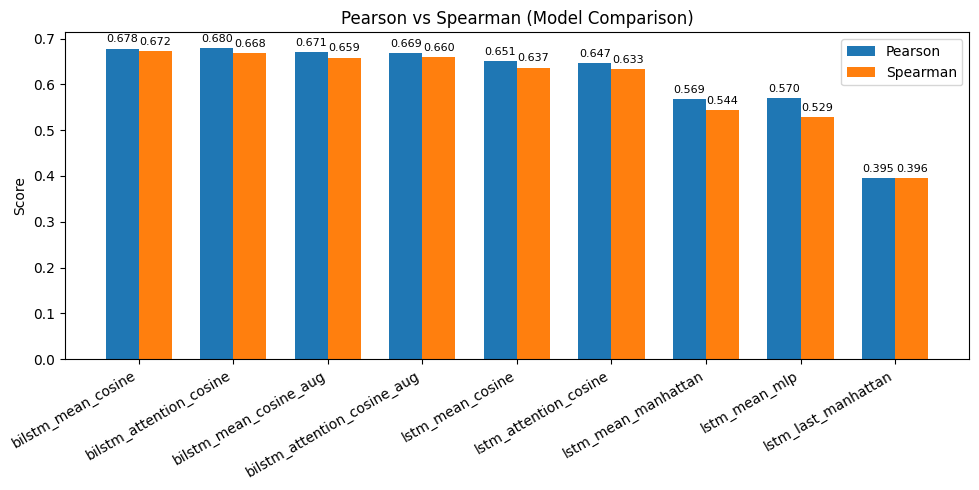

In [10]:
x = range(len(df))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    [i - width/2 for i in x],
    df["test_pearson"],
    width=width,
    label="Pearson"
)

bars2 = plt.bar(
    [i + width/2 for i in x],
    df["test_spearman"],
    width=width,
    label="Spearman"
)

# Mostrar valores sobre cada barra
plt.bar_label(bars1, fmt="%.3f", padding=3, fontsize=8)
plt.bar_label(bars2, fmt="%.3f", padding=3, fontsize=8)

plt.xticks(x, df["name"], rotation=30, ha="right")
plt.ylabel("Score")
plt.title("Pearson vs Spearman (Model Comparison)")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Asigna una clasificación a cada modelo. Una puntuación más alta equivale a una mejor clasificación.
df["pearson_rank"] = df["test_pearson"].rank(ascending=False)
df["spearman_rank"] = df["test_spearman"].rank(ascending=False)

print(df[["name", "pearson_rank", "spearman_rank"]])


                          name  pearson_rank  spearman_rank
2           bilstm_mean_cosine           2.0            1.0
0      bilstm_attention_cosine           1.0            2.0
3       bilstm_mean_cosine_aug           3.0            4.0
1  bilstm_attention_cosine_aug           4.0            3.0
6             lstm_mean_cosine           5.0            5.0
4        lstm_attention_cosine           6.0            6.0
7          lstm_mean_manhattan           8.0            7.0
8                lstm_mean_mlp           7.0            8.0
5          lstm_last_manhattan           9.0            9.0


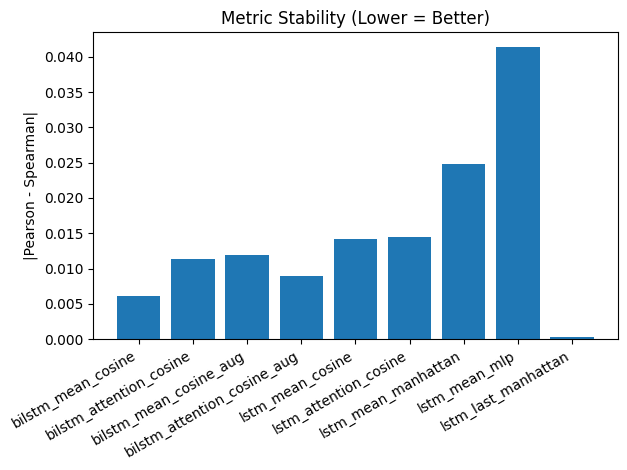

In [12]:
df["gap"] = abs(df["test_pearson"] - df["test_spearman"])

plt.figure()
plt.bar(df["name"], df["gap"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("|Pearson - Spearman|")
plt.title("Metric Stability (Lower = Better)")
plt.tight_layout()
plt.show()


C:\Users\malos\AppData\Local\Temp\ipykernel_24280\3267700184.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["name"], rotation=30, ha="right")


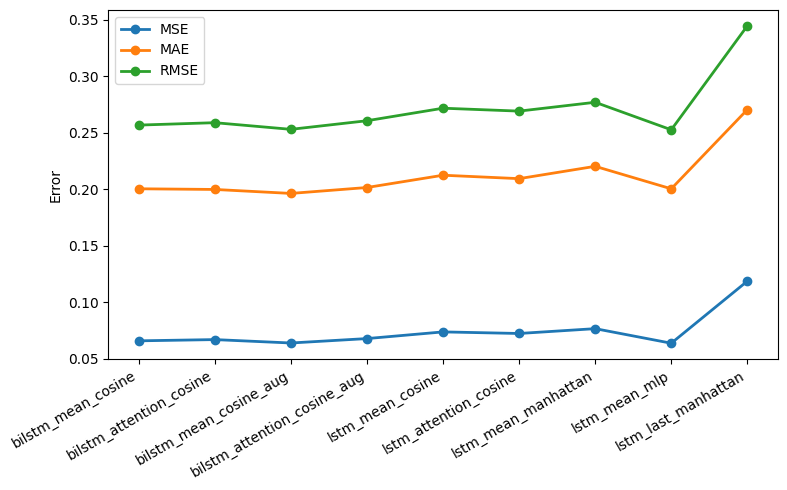

In [13]:
metrics = ["test_mse", "test_mae", "test_rmse"]

fig, ax = plt.subplots(figsize=(8,5))

for metric in metrics:
    ax.plot(df["name"], df[metric], marker="o", linewidth=2, label=metric.replace("test_", "").upper())

ax.set_ylabel("Error")
ax.set_xticklabels(df["name"], rotation=30, ha="right")
ax.legend()
plt.tight_layout()


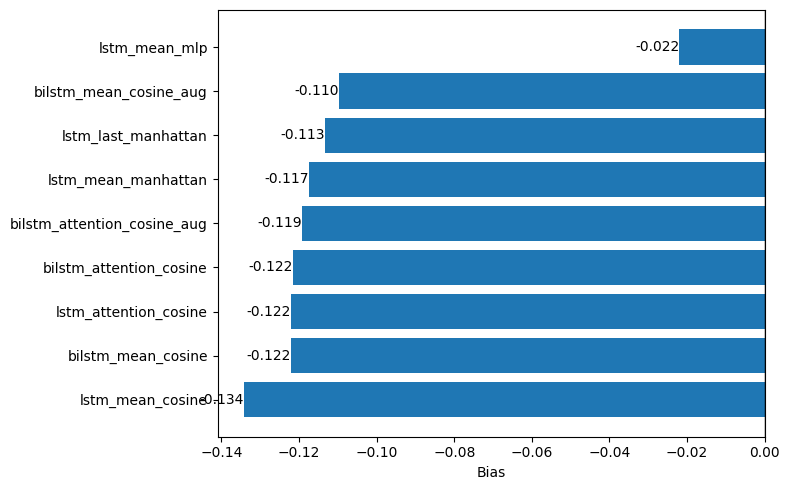

In [14]:
df_bias = df.sort_values("test_bias")

plt.figure(figsize=(8, 5))

colors = ["tab:red" if x > 0 else "tab:blue" for x in df_bias["test_bias"]]

bars = plt.barh(df_bias["name"], df_bias["test_bias"], color=colors)

plt.axvline(0, color="black", linewidth=1)
plt.bar_label(bars, fmt="%.3f")

plt.xlabel("Bias")
plt.tight_layout()
plt.show()


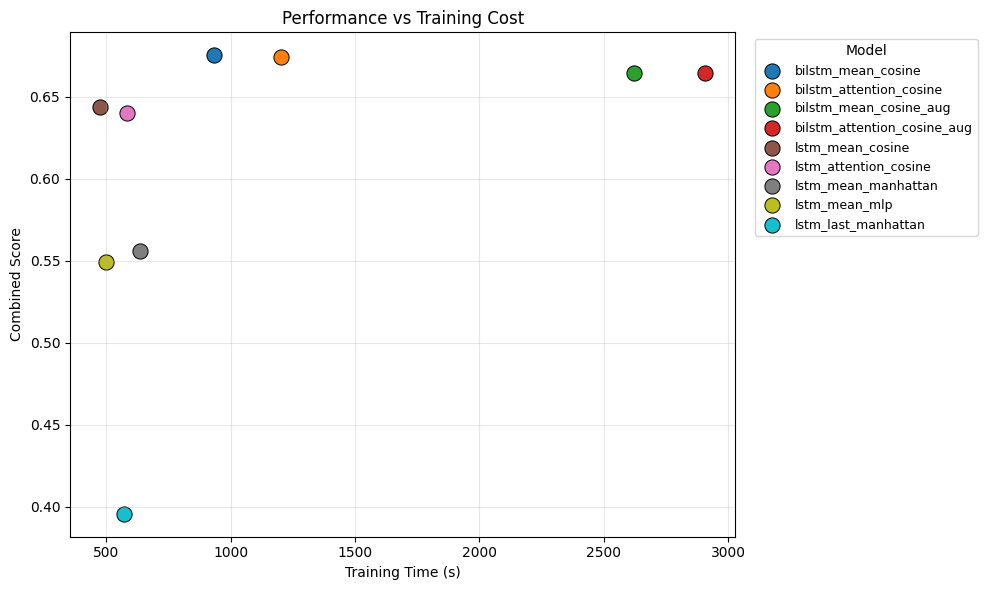

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(df)))

for i, (_, row) in enumerate(df.iterrows()):
    ax.scatter(
        row["train_time_s"],
        row["combined"],
        s=120,
        color=colors[i],
        edgecolor="black",
        linewidth=0.7,
        label=row["name"]
    )

ax.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9
)

ax.set_xlabel("Training Time (s)")
ax.set_ylabel("Combined Score")
ax.set_title("Performance vs Training Cost")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


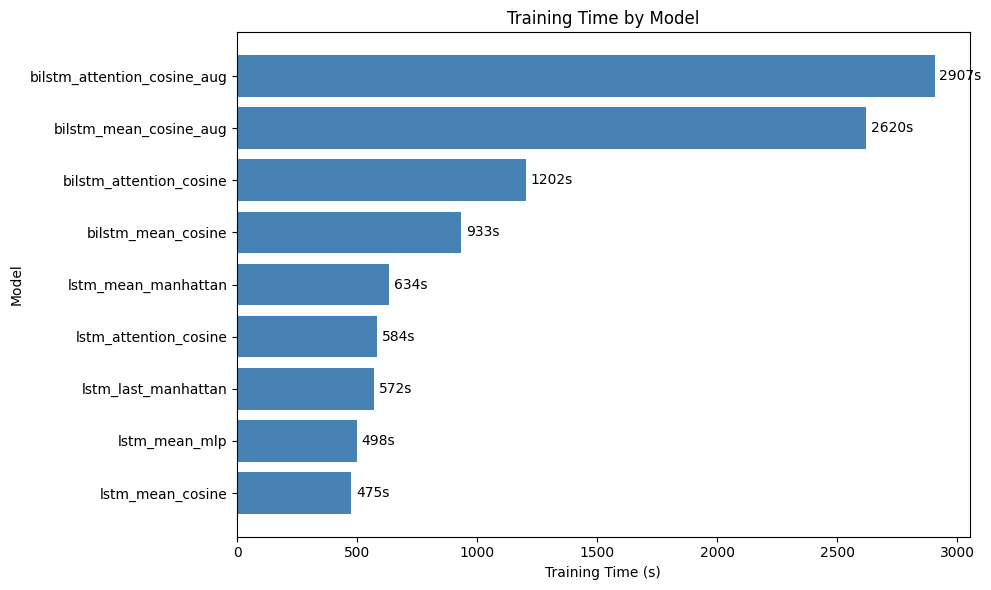

In [16]:
df_sorted = df.sort_values("train_time_s")

plt.figure(figsize=(10, 6))

plt.barh(
    df_sorted["name"],
    df_sorted["train_time_s"],
    color="steelblue"
)

plt.xlabel("Training Time (s)")
plt.ylabel("Model")
plt.title("Training Time by Model")

# Mostrar el valor al final de cada barra
for i, v in enumerate(df_sorted["train_time_s"]):
    plt.text(v + 20, i, f"{v:.0f}s", va="center")

plt.tight_layout()
plt.show()


In [17]:
df["score"] = df["combined"] - df["test_mae"]

df_sorted = df.sort_values("score", ascending=False)

print(df_sorted[["name", "test_pearson", "test_spearman", "test_mae", "score"]])


                          name  test_pearson  test_spearman  test_mae  \
2           bilstm_mean_cosine      0.678489       0.672424  0.200472   
0      bilstm_attention_cosine      0.679829       0.668496  0.199876   
3       bilstm_mean_cosine_aug      0.670564       0.658593  0.196366   
1  bilstm_attention_cosine_aug      0.668983       0.659998  0.201597   
6             lstm_mean_cosine      0.651181       0.636927  0.212470   
4        lstm_attention_cosine      0.647447       0.633049  0.209435   
8                lstm_mean_mlp      0.569922       0.528526  0.200446   
7          lstm_mean_manhattan      0.568524       0.543688  0.220342   
5          lstm_last_manhattan      0.395479       0.395780  0.270501   

      score  
2  0.474984  
0  0.474287  
3  0.468212  
1  0.462893  
6  0.431584  
4  0.430813  
8  0.348778  
7  0.335764  
5  0.125129  


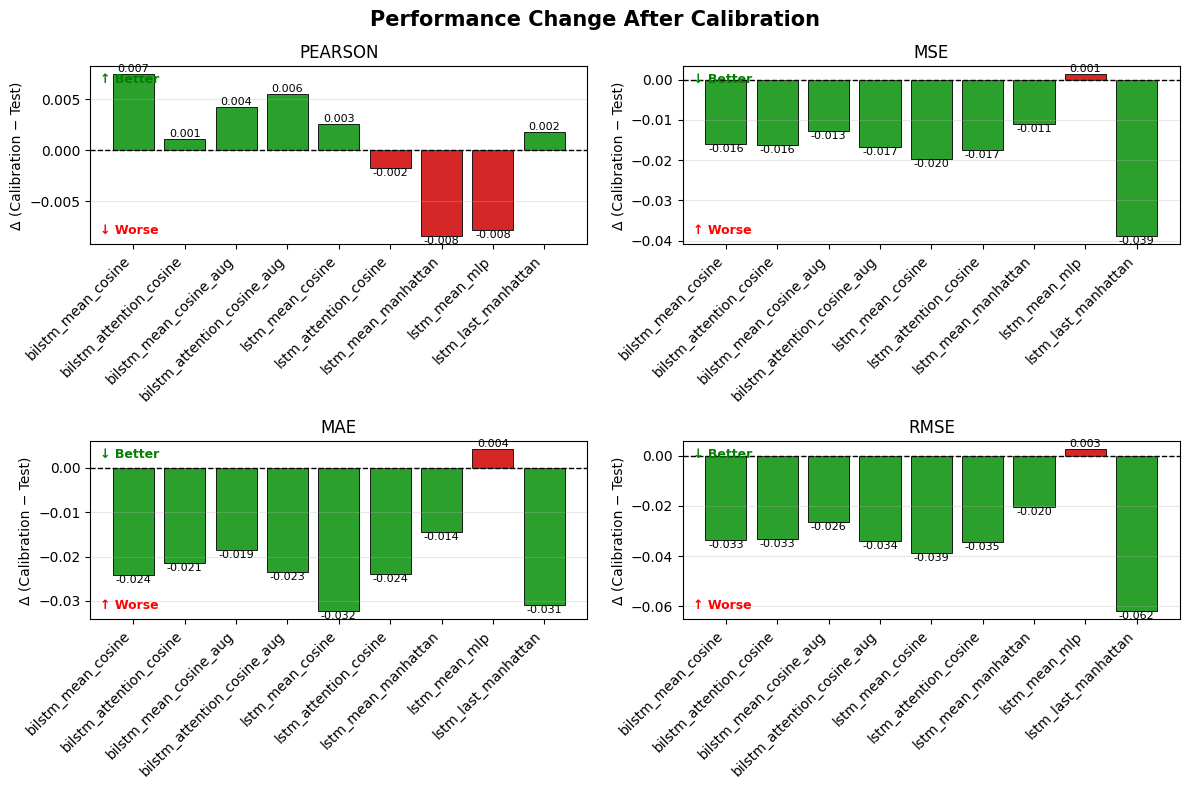

In [18]:
# Más alto --> mejor
pos_metrics = ["pearson"]

# Más bajo --> mejor
neg_metrics = ["mse", "mae", "rmse"]

all_metrics = pos_metrics + neg_metrics

# Delta = Calibration - Test
for metric in all_metrics:
    df[f"delta_{metric}"] = df[f"calibration_{metric}"] - df[f"test_{metric}"]

lower_is_better = set(neg_metrics)

for metric in all_metrics:
    if metric in lower_is_better:
        df[f"cal_win_{metric}"] = df[f"delta_{metric}"] < 0
    else:
        df[f"cal_win_{metric}"] = df[f"delta_{metric}"] > 0

df["n_win"] = df[[f"cal_win_{m}" for m in all_metrics]].sum(axis=1)
df["avg_delta"] = df[[f"delta_{m}" for m in all_metrics]].mean(axis=1)

n_metrics = len(all_metrics)
n_cols = 2
n_rows = math.ceil(n_metrics / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

axes = axes.flatten()

for i, metric in enumerate(all_metrics):
    ax = axes[i]

    delta = df[f"delta_{metric}"]

    if metric in lower_is_better:
        colors = ["tab:green" if d < 0 else "tab:red" for d in delta]
        better_text = "↓ Better"
        worse_text = "↑ Worse"
    else:
        colors = ["tab:green" if d > 0 else "tab:red" for d in delta]
        better_text = "↑ Better"
        worse_text = "↓ Worse"

    bars = ax.bar(
        df["name"],
        delta,
        color=colors,
        edgecolor="black",
        linewidth=0.6
    )

    ax.axhline(0, color="black", linestyle="--", linewidth=1)

    ax.bar_label(bars, fmt="%.3f", fontsize=8)

    ax.text(
        0.02, 0.96,
        better_text,
        transform=ax.transAxes,
        color="green",
        fontsize=9,
        va="top",
        fontweight="bold"
    )

    ax.text(
        0.02, 0.04,
        worse_text,
        transform=ax.transAxes,
        color="red",
        fontsize=9,
        va="bottom",
        fontweight="bold"
    )

    ax.set_title(metric.upper())
    ax.set_ylabel("Δ (Calibration − Test)")
    ax.grid(axis="y", alpha=0.3)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df["name"], rotation=45, ha="right")

# Eliminar ejes sobrantes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Performance Change After Calibration",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()
